Loading BEEMO dataset...
Loaded 2187 samples

Computing edit percentages from BEEMO


Processing: 100%|██████████| 2187/2187 [00:09<00:00, 222.29it/s]



EDIT PERCENTAGE STATISTICS
count    2187.000000
mean       70.488372
std        25.595495
min         0.064034
25%        53.421807
50%        78.103757
75%        92.047213
max        99.782135
Name: edit_percentage, dtype: float64

Distribution by bins:
  (0-20]: 113 samples
  (20-30]: 107 samples
  (30-40]: 124 samples
  (40-50]: 142 samples
  (50-60]: 177 samples
  (60-70]: 215 samples
  (70-80]: 270 samples
  (80-100]: 1039 samples

 Edit percentages saved to beemo_edit_percentages.csv

COMPUTING AUROC BY EDIT BINS FOR ALL DETECTORS

Processing: Binoculars
File: /content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_detailed.csv
Available columns: ['text', 'true_label', 'binoculars_score', 'prediction']
⚙ Inverting Binoculars scores (lower = AI, so multiply by -1)
✓ Using columns - label: 'label', score: 'score'
  Label distribution: {0: 2187, 1: 2187}
  Expert samples: 2187, Machine samples: 2187

  Computing AUROC for each bin:
    (0-20]: 59.34% (n_expert=113, n_machine=1

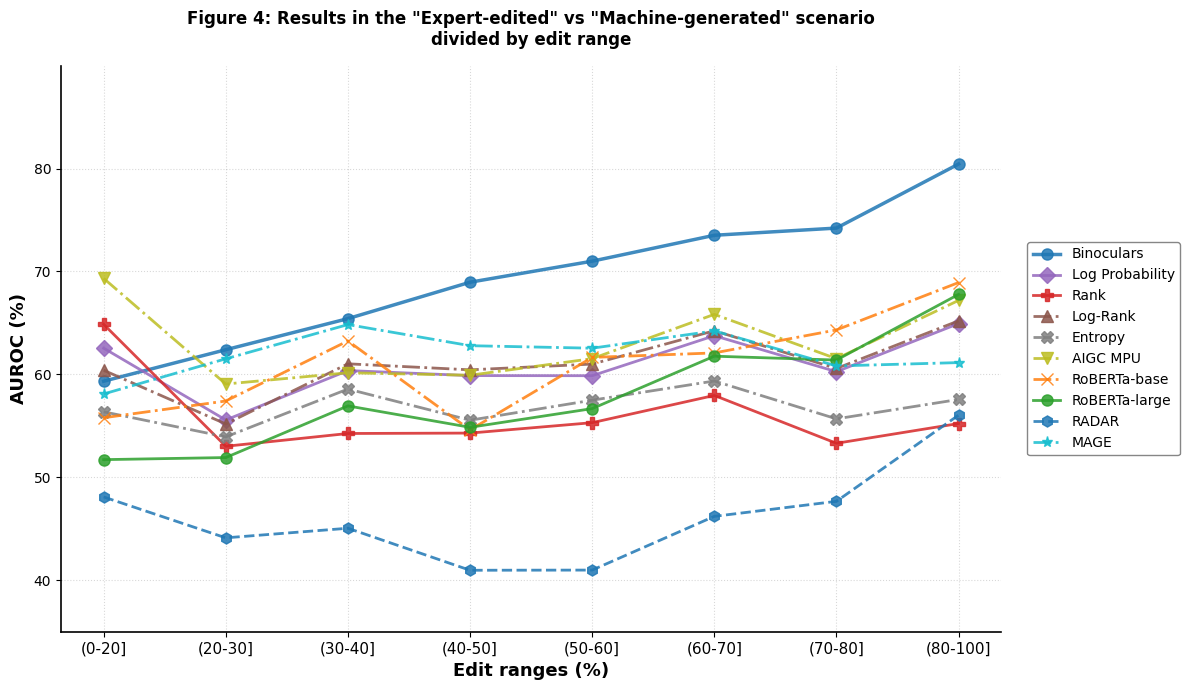


FINAL AUROC BY EDIT BINS (%)
                 (0-20]  (20-30]  (30-40]  (40-50]  (50-60]  (60-70]  (70-80]  \
Binoculars        59.34    62.40    65.42    68.96    71.00    73.52    74.22   
Log Probability   62.55    55.57    60.37    59.88    59.87    63.76    60.26   
Rank              64.87    53.02    54.26    54.30    55.31    57.96    53.31   
Log-Rank          60.40    55.18    61.03    60.44    61.00    64.24    60.58   
Entropy           56.37    53.93    58.58    55.55    57.49    59.36    55.68   
AIGC MPU          69.33    59.07    60.16    59.92    61.53    65.83    61.53   
RoBERTa-base      55.79    57.42    63.25    54.61    61.65    62.09    64.32   
RoBERTa-large     51.72    51.92    56.94    54.86    56.68    61.77    61.39   
RADAR             48.09    44.12    45.05    40.97    40.99    46.21    47.67   
MAGE              58.10    61.52    64.84    62.79    62.55    64.23    60.82   

                 (80-100]  
Binoculars          80.44  
Log Probability     64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import difflib
from tqdm import tqdm
from datasets import load_dataset
from sklearn.metrics import roc_auc_score
import ast

# Load BEEMO dataset once
print("Loading BEEMO dataset...")
beemo_df = load_dataset("toloka/beemo")['train'].to_pandas()
print(f"Loaded {len(beemo_df)} samples")


# EDIT PERCENTAGE FUNCTIONS

def calculate_edit_percentage(original, edited):

    if pd.isna(original) or pd.isna(edited) or original == edited:
        return 0.0

    original = str(original).strip()
    edited = str(edited).strip()

    if not original or not edited:
        return 0.0

    s = difflib.SequenceMatcher(None, original, edited)
    similarity = s.ratio()
    return (1 - similarity) * 100


def extract_text_from_column(value):

    if pd.isna(value):
        return None

    if isinstance(value, str) and not value.strip().startswith('[{'):
        return value.strip()

    if isinstance(value, str) and value.strip().startswith('[{'):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) > 0 and isinstance(parsed[0], dict):
                for key in ['P1', 'P2', 'P3']:
                    if key in parsed[0]:
                        return str(parsed[0][key]).strip()
        except:
            pass

    return str(value).strip()


def compute_edit_percentages_for_beemo():
    print("\nComputing edit percentages from BEEMO")

    edit_data = []

    for _, row in tqdm(beemo_df.iterrows(), total=len(beemo_df), desc="Processing"):
        machine_text = extract_text_from_column(row['model_output'])
        expert_edited = extract_text_from_column(row['human_edits'])

        if machine_text and expert_edited:
            edit_pct = calculate_edit_percentage(machine_text, expert_edited)
            edit_data.append({
                'machine_text': machine_text,
                'expert_edited': expert_edited,
                'edit_percentage': edit_pct,
                'prompt': row.get('prompt', ''),
                'category': row.get('category', '')
            })

    return pd.DataFrame(edit_data)

# MAIN AUROC COMPUTATION
def compute_auroc_by_edit_bins(detector_csv_path, edit_percentages_df, detector_name=""):

    df = pd.read_csv(detector_csv_path)

    print(f"\n{'='*70}")
    print(f"Processing: {detector_name}")
    print(f"File: {detector_csv_path}")
    print(f"Available columns: {df.columns.tolist()}")

    original_score_column = None

    if 'true_label' in df.columns:
        df = df.rename(columns={'true_label': 'label'})
    elif 'Label' in df.columns:
        df = df.rename(columns={'Label': 'label'})

    if 'binoculars_score' in df.columns:
        original_score_column = 'binoculars_score'
        df = df.rename(columns={'binoculars_score': 'score'})
    elif 'entropy_score' in df.columns:
        original_score_column = 'entropy_score'
        df = df.rename(columns={'entropy_score': 'score'})
    elif 'prediction' in df.columns and 'score' not in df.columns:
        original_score_column = 'prediction'
        df = df.rename(columns={'prediction': 'score'})
    elif 'Prediction' in df.columns and 'score' not in df.columns:
        original_score_column = 'Prediction'
        df = df.rename(columns={'Prediction': 'score'})

    if original_score_column in ['binoculars_score', 'prediction'] or \
       'binoculars' in detector_csv_path.lower():
        print("⚙ Inverting Binoculars scores (lower = AI, so multiply by -1)")
        df['score'] = -df['score']

    if original_score_column == 'entropy_score' or 'entropy' in detector_csv_path.lower():
        print("⚙ Inverting Entropy scores (lower = AI, so multiply by -1)")
        df['score'] = -df['score']

    if 'label' not in df.columns:
        raise ValueError(f"No 'label' column found. Available: {df.columns.tolist()}")

    if 'score' not in df.columns:
        raise ValueError(f"No 'score' column found. Available: {df.columns.tolist()}")

    print(f"✓ Using columns - label: 'label', score: 'score'")
    print(f"  Label distribution: {df['label'].value_counts().to_dict()}")

    expert_samples = df[df['label'] == 0].copy()
    if len(expert_samples) > len(edit_percentages_df):
        expert_samples = expert_samples.iloc[:len(edit_percentages_df)]

    expert_samples['edit_percentage'] = edit_percentages_df['edit_percentage'].values[:len(expert_samples)]

    machine_samples = df[df['label'] == 1].copy()

    print(f"  Expert samples: {len(expert_samples)}, Machine samples: {len(machine_samples)}")

    bins = [(0, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 70), (70, 80), (80, 100)]
    bin_labels = ['(0-20]', '(20-30]', '(30-40]', '(40-50]', '(50-60]', '(60-70]', '(70-80]', '(80-100]']

    results = {}

    print(f"\n  Computing AUROC for each bin:")
    for (low, high), label in zip(bins, bin_labels):
        # Get expert samples in this edit range
        mask = (expert_samples['edit_percentage'] > low) & \
               (expert_samples['edit_percentage'] <= high)
        expert_in_bin = expert_samples[mask]

        n_expert = len(expert_in_bin)

        if n_expert == 0:
            print(f"    {label}: No expert samples - SKIPPED")
            results[label] = np.nan
            continue
        n_machine = min(n_expert, len(machine_samples))
        machine_sampled = machine_samples.sample(n=n_machine, random_state=42, replace=False)
        combined = pd.concat([expert_in_bin, machine_sampled])

        try:
            auroc = roc_auc_score(combined['label'], combined['score']) * 100
            results[label] = auroc
            print(f"    {label}: {auroc:.2f}% (n_expert={n_expert}, n_machine={n_machine})")
        except Exception as e:
            print(f"    {label}: ERROR - {e}")
            results[label] = np.nan

    print(f"{'='*70}")
    return pd.Series(results)

# STEP 1: COMPUTE EDIT PERCENTAGES
edit_pct_df = compute_edit_percentages_for_beemo()

print("\n" + "="*70)
print("EDIT PERCENTAGE STATISTICS")
print("="*70)
print(edit_pct_df['edit_percentage'].describe())
print("\nDistribution by bins:")
bins = [(0, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 70), (70, 80), (80, 100)]
for low, high in bins:
    count = ((edit_pct_df['edit_percentage'] > low) &
             (edit_pct_df['edit_percentage'] <= high)).sum()
    print(f"  ({low}-{high}]: {count} samples")
print("="*70)

edit_pct_df.to_csv('beemo_edit_percentages.csv', index=False)
print("\n Edit percentages saved to beemo_edit_percentages.csv")

# PROCESS ALL DETECTORS
detector_results = {}

detectors = {
    'Binoculars': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_detailed.csv',
    'Log Probability': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_logprob_gpt2xl.csv',
    'Rank': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_rank_gpt2-xl.csv',
    'Log-Rank': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_logrank_gpt2-xl.csv',
    'Entropy': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_entropy_openai-community_gpt2-xl.csv',
    'AIGC MPU': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_aigc_mpu.csv',
    'RoBERTa-base': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_roberta-base-openai-detector.csv',
    'RoBERTa-large': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_roberta-large-openai-detector.csv',
    'RADAR': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_radar.csv',
    'MAGE': '/content/drive/MyDrive/BEEMO_Reproducibility/results/E_vs_M_mage.csv',
}

print("\n" + "="*70)
print("COMPUTING AUROC BY EDIT BINS FOR ALL DETECTORS")
print("="*70)

for detector_name, csv_file in detectors.items():
    try:
        results = compute_auroc_by_edit_bins(csv_file, edit_pct_df, detector_name)
        detector_results[detector_name] = results
        print(f"\n {detector_name} - done")
    except Exception as e:
        print(f"\n {detector_name} - done: {e}")
        import traceback
        traceback.print_exc()


# CREATE FIGURE 4

def create_figure4(detector_results):

    fig, ax = plt.subplots(figsize=(12, 7))

    # Define colors and markers
    style_map = {
        'Binoculars': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-', 'linewidth': 2.5},
        'DetectGPT': {'color': '#ff7f0e', 'marker': 'x', 'linestyle': '-', 'linewidth': 2},
        'DetectLLM NPR': {'color': '#2ca02c', 'marker': 's', 'linestyle': '-.', 'linewidth': 2},
        'Rank': {'color': '#d62728', 'marker': 'P', 'linestyle': '-', 'linewidth': 2},
        'Log Probability': {'color': '#9467bd', 'marker': 'D', 'linestyle': '-', 'linewidth': 2},
        'Log-Rank': {'color': '#8c564b', 'marker': '^', 'linestyle': '-.', 'linewidth': 2},
        'DetectLLM LRR': {'color': '#e377c2', 'marker': '^', 'linestyle': '-.', 'linewidth': 2},
        'Entropy': {'color': '#7f7f7f', 'marker': 'X', 'linestyle': '-.', 'linewidth': 2},
        'AIGC MPU': {'color': '#bcbd22', 'marker': 'v', 'linestyle': '-.', 'linewidth': 2},
        'MAGE': {'color': '#17becf', 'marker': '*', 'linestyle': '-.', 'linewidth': 2},
        'RADAR': {'color': '#1f77b4', 'marker': 'h', 'linestyle': '--', 'linewidth': 2},
        'RoBERTa-base': {'color': '#ff7f0e', 'marker': 'x', 'linestyle': '-.', 'linewidth': 2},
        'RoBERTa-large': {'color': '#2ca02c', 'marker': 'o', 'linestyle': '-', 'linewidth': 2},
    }

    x_labels = ['(0-20]', '(20-30]', '(30-40]', '(40-50]', '(50-60]', '(60-70]', '(70-80]', '(80-100]']
    x = np.arange(len(x_labels))

    # Plot each detector
    for detector_name, scores in detector_results.items():
        style = style_map.get(detector_name, {'color': 'gray', 'marker': 'o', 'linestyle': '-', 'linewidth': 2})

        ax.plot(
            x, scores.values,
            marker=style['marker'],
            label=detector_name,
            linewidth=style['linewidth'],
            markersize=8,
            color=style['color'],
            linestyle=style['linestyle'],
            alpha=0.85
        )


    # Formatting
    ax.set_xlabel('Edit ranges (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('AUROC (%)', fontsize=13, fontweight='bold')
    ax.set_title('Figure 4: Results in the "Expert-edited" vs "Machine-generated" scenario\ndivided by edit range',
                 fontsize=12, fontweight='bold', pad=15)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_ylim(35, 90)
    ax.set_yticks(range(40, 85, 10))

    # Grid
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8, color='gray')
    ax.set_axisbelow(True)

    # Legend - place outside plot area
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, frameon=True, fancybox=True,
             edgecolor='gray', framealpha=0.95, ncol=1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    plt.tight_layout()
    plt.savefig('Figure4_Reproduction.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("\n image saved")
    plt.show()


# Generate Figure 4
if detector_results:
    create_figure4(detector_results)
else:
    print("No detector results to plot")


# SAVE AND DISPLAY RESULTS
results_df = pd.DataFrame(detector_results).T
results_df.to_csv('figure4_auroc_by_edit_bins.csv')

print("\n" + "="*70)
print("FINAL AUROC BY EDIT BINS (%)")
print("="*70)
print(results_df.round(2))
print("="*70)

# Calculate and show averages
print("\nAverage AUROC across all bins:")
for detector in results_df.index:
    avg = results_df.loc[detector].mean()
    print(f"  {detector:20s}: {avg:.2f}%")
print("="*70)